# Parallelism Surfaces
This notebook computes packing grids and renders computational-parallelism surfaces for the single-device and cross-device cases.


In [1]:
# Purpose: Import numerical, optimization, and plotting dependencies.
import json
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.optimize import minimize, linprog, milp, Bounds, LinearConstraint
import functools

try:
    from adjustText import adjust_text
except ModuleNotFoundError:
    def adjust_text(*_args, **_kwargs):
        """Use a no-op fallback when adjustText is unavailable."""
        return []


plt.rcParams["font.family"] = (
    "serif" 
)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
mpl.rcParams['hatch.linewidth'] = 1


In [2]:
# Purpose: Define a reusable color-gradient helper for plotting utilities.
def color_gradient(c1, c2, steps, use_hsv=True):
    if steps == 1:
        return [c1]
    if steps == 0:
        return []
    cc1 = mpl.colors.to_rgb(c1)
    cc2 = mpl.colors.to_rgb(c2)
    if use_hsv:
        cc1 = mpl.colors.rgb_to_hsv(cc1)
        cc2 = mpl.colors.rgb_to_hsv(cc2)
    step = [(cc2[i] - cc1[i]) / (steps - 1) for i in range(3)]
    cs = [[(cc1[j] + step[j] * i) for j in range(3)] for i in range(steps)]
    if use_hsv:
        cs = mpl.colors.hsv_to_rgb(cs)
    return [mpl.colors.to_hex(c) for c in cs]


In [3]:
# Purpose: Define Pareto-front detection used by layout frontier plots.
def find_pareto_front(solutions):
    num_solutions = solutions.shape[0]
    is_pareto = np.ones(num_solutions, dtype=bool)

    for i in range(num_solutions):
        for j in range(num_solutions):
            if i == j:
                continue

            all_j_le_i = np.all(solutions[j] <= solutions[i])
            any_j_lt_i = np.any(solutions[j] < solutions[i])

            if all_j_le_i and any_j_lt_i:
                is_pareto[i] = False
                break

    return is_pareto


In [4]:
# Purpose: Define layout-position, overlap-checking, and layout-visualization helpers.
from matplotlib import patches


def get_pos(n, W, pn):
    if n == 1:
        return [0]
    pos = [0] * n
    if n > 1 and pn == 0:
        pad = 0
    elif n > 1:
        pad = pn // (n - 1)
    else:
        pad = 0
    for i in range(n - 1):
        pos[i + 1] = pos[i] + pad
        if i < pn % (n - 1):
            pos[i + 1] += 1
    return pos


def _get_layout_positions(r):
    if "x_pos" in r and "y_pos" in r:
        return list(r["x_pos"]), list(r["y_pos"])

    nx, ny, xn, yn = r["nx"], r["ny"], r["xn"], r["yn"]
    X, Y = r["X"], r["Y"]
    x_pos = get_pos(nx, X, xn)
    y_pos = get_pos(ny, Y, yn)
    return x_pos, y_pos


def _format_layout_summary(r, R_lim=None):
    T = r.get("T", r["nx"] * r["ny"])
    cost = r.get("cost")
    if cost is None:
        cost_text = "-"
    else:
        cost_text = f"{float(cost):.2f}"
    max_pairwise_overlap = _get_max_result_overlap(r)
    if R_lim is None:
        max_pointwise_overlap = "-"
    else:
        max_pointwise_overlap = _get_max_pointwise_overlap(r, R_lim)
    return (
        f"nx={r['nx']}, ny={r['ny']}, T={T}, cost={cost_text}, "
        f"max_pairwise_overlap={max_pairwise_overlap}, "
        f"max_pointwise_overlap={max_pointwise_overlap}"
    )


def _build_layout_xticks(R_lim):
    if R_lim <= 16:
        step = 4
    elif R_lim <= 32:
        step = 8
    else:
        step = 8
    ticks = list(range(0, R_lim + 1, step))
    if ticks[-1] != R_lim:
        ticks.append(R_lim)
    return ticks


MAX_RESULT_OVERLAP = 3


def _get_min_result_spacing(result_width, max_result_overlap=MAX_RESULT_OVERLAP):
    return max(0, int(result_width - max_result_overlap))


def _get_result_starts_from_layout(r):
    x_pos, y_pos = _get_layout_positions(r)
    return sorted(x + y for x in x_pos for y in y_pos)


def _calc_adjacent_result_overlaps(result_starts, result_width):
    if len(result_starts) <= 1:
        return []
    return [
        max(0, int(result_width - (right - left)))
        for left, right in zip(result_starts[:-1], result_starts[1:])
    ]


def _get_max_result_overlap(r):
    result_starts = _get_result_starts_from_layout(r)
    overlaps = _calc_adjacent_result_overlaps(result_starts, r["X"] + r["Y"])
    return max(overlaps) if overlaps else 0


def _get_max_pointwise_overlap(r, R_lim):
    result_width = r["X"] + r["Y"]
    result_starts = _get_result_starts_from_layout(r)
    if not result_starts:
        return -1
    if result_starts[0] < 0 or result_starts[-1] + result_width > R_lim:
        return -1

    overlap = [0] * R_lim
    for start in result_starts:
        for idx in range(start, start + result_width):
            overlap[idx] += 1
    return max(overlap, default=0)


def overlap_check(r, R_lim):
    result_width = r["X"] + r["Y"]
    result_starts = _get_result_starts_from_layout(r)
    if not result_starts:
        return False
    if result_starts[0] < 0:
        return False
    if result_starts[-1] + result_width > R_lim:
        return False

    max_result_overlap = int(r.get("max_result_overlap", MAX_RESULT_OVERLAP))
    min_result_spacing = _get_min_result_spacing(result_width, max_result_overlap)
    spacing_ok = all(
        (right - left) >= min_result_spacing
        for left, right in zip(result_starts[:-1], result_starts[1:])
    )
    pointwise_ok = _get_max_pointwise_overlap(r, R_lim) <= 2
    return spacing_ok and pointwise_ok


def visualize(r, R_lim):
    X, Y, X_lim, Y_lim = r["X"], r["Y"], r["X_lim"], r["Y_lim"]
    x_pos, y_pos = _get_layout_positions(r)

    def get_bar(lim):
        return ["⬜"] * lim + ["⬛"] * max(R_lim - lim, 0)

    x_bar = get_bar(X_lim + 1)
    y_bar = get_bar(Y_lim + 1)
    r_bar = get_bar(R_lim)
    for px in x_pos:
        for i in range(X):
            if 0 <= px + i < len(x_bar):
                x_bar[px + i] = "🟦"
    for py in y_pos:
        for i in range(Y):
            if 0 <= py + i < len(y_bar):
                y_bar[py + i] = "🟨"
    for px in x_pos:
        for py in y_pos:
            for i in range(X + Y):
                idx = px + py + i
                if 0 <= idx < len(r_bar):
                    if r_bar[idx] != "⬜":
                        r_bar[idx] = "🟥"
                    else:
                        r_bar[idx] = "🟩"

    print(_format_layout_summary(r, R_lim))
    if X_lim < Y_lim:
        print("B: " + "".join(reversed(x_bar)))
        print("A: " + "".join(reversed(y_bar)))
    else:
        print("B: " + "".join(reversed(y_bar)))
        print("A: " + "".join(reversed(x_bar)))
    print("P: " + "".join(reversed(r_bar)))


def visualize_pdf(r, R_lim, ax=None):
    X, Y, X_lim, Y_lim = r["X"], r["Y"], r["X_lim"], r["Y_lim"]
    x_pos, y_pos = _get_layout_positions(r)

    if not ax:
        fig, ax = plt.subplots(figsize=(10, 1.5))
    track_height = 0.8

    track_P_y = 0.5
    if X_lim > Y_lim:
        track_A_y = 1.5
        track_B_y = 2.5
    else:
        track_A_y = 2.5
        track_B_y = 1.5

    ax.add_patch(
        patches.Rectangle(
            (0, track_B_y - track_height / 2),
            Y_lim + 1,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (0, track_A_y - track_height / 2),
            X_lim + 1,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (0, track_P_y - track_height / 2),
            R_lim,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )

    x_colors = color_gradient("#84baf5", "#347dcb", len(x_pos))
    for px, c in zip(x_pos, x_colors):
        ax.add_patch(
            patches.Rectangle(
                (px, track_A_y - track_height / 2),
                X,
                track_height,
                facecolor=c,
                edgecolor="black",
                zorder=10,
            )
        )

    y_colors = color_gradient("#fca34a", "#ff8205", len(y_pos))
    for py, c in zip(y_pos, y_colors):
        ax.add_patch(
            patches.Rectangle(
                (py, track_B_y - track_height / 2),
                Y,
                track_height,
                facecolor=c,
                edgecolor="black",
                zorder=10,
            )
        )

    positions = [px + py for px in x_pos for py in y_pos]
    positions.sort()
    res_colors = color_gradient("#14c142", "#0d7c2a", len(positions))
    for start_pos, c in zip(positions, res_colors):
        draw_width = min(X + Y, R_lim - start_pos)
        if draw_width > 0:
            ax.add_patch(
                patches.Rectangle(
                    (start_pos, track_P_y - track_height / 2),
                    draw_width,
                    track_height,
                    facecolor=c,
                    edgecolor="black",
                    alpha=0.7,
                    zorder=11,
                )
            )

    ax.set_xlim(R_lim, 0)
    ax.set_ylim(0, 3.5)
    ax.set_xticks(_build_layout_xticks(R_lim))

    track_labels = ["P", "A", "B"]
    ax.set_yticks([track_P_y, track_A_y, track_B_y])
    ax.set_yticklabels(track_labels, fontsize=12)
    ax.tick_params(axis="y", which="both", length=0)
    ax.set_title(_format_layout_summary(r, R_lim), fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


In [5]:

# Purpose: Define the integer layout search and feasible-candidate enumeration routines.
def solve(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    width = X + Y
    min_result_spacing = _get_min_result_spacing(width)
    best = None

    def try_candidate(xn, yn):
        nonlocal best
        r = {
            "nx": n1,
            "ny": n2,
            "X": X,
            "Y": Y,
            "X_lim": X_lim,
            "Y_lim": Y_lim,
            "xn": int(xn),
            "yn": int(yn),
            "max_result_overlap": MAX_RESULT_OVERLAP,
        }
        if not overlap_check(r, R_lim):
            return

        cost = (n1 * n2 - 1) * width - (xn + yn)
        candidate = (float(cost), int(xn), int(yn))
        if best is None or candidate < best:
            best = candidate

    if n1 == 1:
        y_low = int((n2 - 1) * max(Y, min_result_spacing))
        y_high = int(min(Y_lim - Y, R_lim - width, width * (n2 - 1)))
        if Y * n2 > Y_lim or y_low > y_high:
            return -1, -1, -1
        for yn in range(y_low, y_high + 1):
            try_candidate(0, yn)
    elif n2 == 1:
        x_low = int((n1 - 1) * max(X, min_result_spacing))
        x_high = int(min(X_lim - X, R_lim - width, width * (n1 - 1)))
        if X * n1 > X_lim or x_low > x_high:
            return -1, -1, -1
        for xn in range(x_low, x_high + 1):
            try_candidate(xn, 0)
    else:
        b_ub = [
            R_lim - width,
            (MAX_RESULT_OVERLAP - width) * (n2 - 1),
            (n2 - 1) * width,
        ]
        x_low = int((n1 - 1) * max(width - MAX_RESULT_OVERLAP, X))
        x_high = int(min(X_lim - X, (n1 - 1) * width))
        y_low = int(n2 - 1)
        y_high = int(Y_lim - Y)
        if x_low > x_high or y_low > y_high:
            return -1, -1, -1

        for xn in range(x_low, x_high + 1):
            for yn in range(y_low, y_high + 1):
                lhs = [xn + yn, (n2 - 1) * xn - yn, (1 - n2) * xn + yn]
                if any(a > b for a, b in zip(lhs, b_ub)):
                    continue
                try_candidate(xn, yn)

    if best is None:
        return -1, -1, -1
    return best[1], best[2], best[0]

def iter_feasible_xy(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    """Enumerate uniformly spaced candidates that may pass overlap_check under the current rules."""
    if n1 == 1 and n2 == 1:
        return

    if n1 == 1:
        min_result_spacing = _get_min_result_spacing(X + Y)
        y_low = int((n2 - 1) * max(Y, min_result_spacing))
        y_high = int(min(Y_lim - Y, R_lim - X - Y, (X + Y) * (n2 - 1)))
        if Y * n2 > Y_lim or y_low > y_high:
            return
        for yn in range(y_high, y_low - 1, -1):
            yield 0, yn
        return

    if n2 == 1:
        min_result_spacing = _get_min_result_spacing(X + Y)
        x_low = int((n1 - 1) * max(X, min_result_spacing))
        x_high = int(min(X_lim - X, R_lim - X - Y, (X + Y) * (n1 - 1)))
        if X * n1 > X_lim or x_low > x_high:
            return
        for xn in range(x_high, x_low - 1, -1):
            yield xn, 0
        return

    # Round up the minimum x-spacing so the search starts at the first integer layout that can satisfy the overlap limit.
    x_low = int(np.ceil((n1 - 1) * max(X + Y - MAX_RESULT_OVERLAP, X)))
    x_high = int(np.floor(min(X_lim - X, (n1 - 1) * (X + Y))))
    # Round up the baseline y-spacing to keep row positions on integer layout coordinates.
    y_base_low = int(np.ceil(n2 - 1))
    y_base_high = int(np.floor(Y_lim - Y))
    if x_low > x_high or y_base_low > y_base_high:
        return

    for xn in range(x_high, x_low - 1, -1):
        # Round up the y lower bound imposed by the current x-spacing and result-overlap constraint.
        y_low = max(y_base_low, int(np.ceil((n2 - 1) * (xn + X + Y - MAX_RESULT_OVERLAP))))
        y_high = min(
            y_base_high,
            int(np.floor(R_lim - X - Y - xn)),
            int(np.floor((n2 - 1) * (xn + X + Y))),
        )
        if y_low > y_high:
            continue
        for yn in range(y_high, y_low - 1, -1):
            yield xn, yn


def solve_feasible(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    """Find the best feasible configuration for (n1, n2) without missing candidates in the current model."""
    def build_result(xn, yn):
        return {
            "nx": n1,
            "ny": n2,
            "T": n1 * n2,
            "cost": float((n1 * n2 - 1) * (X + Y) - (xn + yn)),
            "X": X,
            "Y": Y,
            "X_lim": X_lim,
            "Y_lim": Y_lim,
            "max_result_overlap": MAX_RESULT_OVERLAP,
            "xn": int(xn),
            "yn": int(yn),
        }

    xn_lp, yn_lp, _ = solve(n1, n2, X, Y, X_lim, Y_lim, R_lim)
    if xn_lp >= 0:
        lp_result = build_result(int(xn_lp), int(yn_lp))
        if overlap_check(lp_result, R_lim):
            return lp_result

    best_result = None
    for xn, yn in iter_feasible_xy(n1, n2, X, Y, X_lim, Y_lim, R_lim):
        candidate = build_result(int(xn), int(yn))
        if overlap_check(candidate, R_lim):
            if best_result is None or candidate["cost"] < best_result["cost"]:
                best_result = candidate

    return best_result


In [6]:
# Purpose: Enumerate feasible layout candidates for a specific precision and DSP configuration.
def solve_all(X, Y, X_lim, Y_lim, R_lim, label="", verbose=False):
    results = []
    for n1 in range(1, X_lim // X + 1):
        for n2 in range(1, Y_lim // Y + 1):
            if n1 == 1 and n2 == 1:
                continue

            best_result = solve_feasible(n1, n2, X, Y, X_lim, Y_lim, R_lim)
            if best_result is not None:
                best_result["label"] = label
                results.append(best_result)
                if verbose:
                    print(f"{n1} {n2} {best_result['cost']}")
                continue

            if verbose:
                print(f"{n1} {n2} NO")
    return results


In [7]:
# Purpose: Cache complete layout candidate enumeration for repeated precision queries.
@functools.cache
def solve_all_4(X, Y, X_lim, Y_lim, R_lim):
    res = []
    res += solve_all(X, Y, X_lim, Y_lim, R_lim, label="A")
    res += solve_all(Y, X, X_lim, Y_lim, R_lim, label="B")
    res += solve_all(X, Y, Y_lim, X_lim, R_lim, label="C")
    res += solve_all(Y, X, Y_lim, X_lim, R_lim, label="D")

    used_config = []
    unique_res = []
    for r in res:
        x_cfg = (r["nx"], r["X"], r["xn"], r["X_lim"])
        y_cfg = (r["ny"], r["Y"], r["yn"], r["Y_lim"])
        if (x_cfg, y_cfg) not in used_config:
            unique_res.append(r)
            used_config.append((x_cfg, y_cfg))
            used_config.append((y_cfg, x_cfg))

    return unique_res


In [8]:
# Purpose: Define Pareto-front plotting for solver-generated layouts.
from matplotlib.ticker import FormatStrFormatter


def solve_and_draw(X, Y, X_lim, Y_lim, R_lim, ax=None, vis="pdf"):
    print(f"INT{X+1} x INT{Y+1}")

    res = solve_all_4(X, Y, X_lim, Y_lim, R_lim)
    if not res:
        print("Uniform-model maximum packing: 0")
        return 0

    for r in res:
        r["T_d"] = r["ny"] if r["X"] == Y else r["nx"]

    if not ax:
        fig, ax = plt.subplots()

    sol = np.array([[1 / r["T"], r["cost"] / r["T"]] for r in res])
    is_pareto = find_pareto_front(sol)
    uniform_max_packing = int(max(r["T"] for idx, r in enumerate(res) if is_pareto[idx]))

    sol_decoding = np.array([[1 / r["T_d"], r["cost"] / r["T_d"]] for r in res])
    is_pareto_decoding = find_pareto_front(sol_decoding)

    def vis_all(pareto, name):
        if vis == "console":
            print(name)
            for idx, p in enumerate(pareto):
                if p:
                    visualize(res[idx], R_lim)
        elif vis == "pdf":
            pareto_cnt = int(pareto.sum())
            if pareto_cnt == 0:
                return
            fig, axs = plt.subplots(nrows=pareto_cnt, figsize=(10, 1.5 * pareto_cnt))
            if pareto_cnt == 1:
                axs = [axs]
            out_idx = 0
            for idx, p in enumerate(pareto):
                if p:
                    visualize_pdf(res[idx], R_lim, ax=axs[out_idx])
                    out_idx += 1
            fig.tight_layout()

    vis_all(is_pareto, "PREFILL")
    vis_all(is_pareto_decoding, "DECODING")

    plotted_positions = []
    txts = []
    for idx, s in enumerate(sol):
        point_key = (round(float(s[0]), 10), round(float(s[1]), 10))
        if point_key in plotted_positions:
            continue
        color = "lightgray"
        if is_pareto[idx]:
            color = "red"
        if is_pareto_decoding[idx]:
            color = "blue"
        ax.scatter(*s, c=color)
        if is_pareto[idx] or is_pareto_decoding[idx]:
            r = res[idx]
            txt = ax.annotate(
                f" ({r['nx']},{r['ny']})",
                s,
                va="center",
                fontsize=18,
            )
            plotted_positions.append(point_key)
            txts.append(txt)

    bbox_props = dict(
        boxstyle="round",
        facecolor="gray",
        alpha=0.2,
        edgecolor="black",
        linestyle="--",
    )

    ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.7)
    ax.text(
        0.9,
        0.9,
        f"W{X+1}A{Y+1}",
        transform=ax.transAxes,
        fontsize=30,
        fontweight="bold",
        ha="right",
        va="top",
        bbox=bbox_props,
    )
    ax.tick_params(axis="both", which="both", labelsize=18)

    def link_points(points, **args):
        front = sol[points]
        if len(front) == 0:
            return
        front_sorted = front[front[:, 0].argsort()]
        ax.plot(front_sorted[:, 0], front_sorted[:, 1], **args)

    link_points(is_pareto, c="r", linestyle="--", label="Uniform Pareto Frontier")
    link_points(
        is_pareto_decoding,
        c="b",
        linestyle="--",
        label="Uniform Decoding Frontier",
    )

    ax.set_xscale("log")
    ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
    formatter = FormatStrFormatter("%.1f")
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    adjust_text(txts, ax=ax)
    print(f"Uniform-model maximum packing: {uniform_max_packing}")
    plt.show()
    return uniform_max_packing


In [9]:
# Purpose: Define packing-grid and 3D surface plotting helpers for computational parallelism.
from scipy.interpolate import RectBivariateSpline
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import LinearSegmentedColormap




def get_singleton_packing_count(X, Y, X_lim, Y_lim, R_lim):
    if X > X_lim or Y > Y_lim:
        return 0
    if X + Y > R_lim:
        return 0
    return 1


@functools.lru_cache(maxsize=None)
def get_uniform_max_packing_count(X, Y, X_lim, Y_lim, R_lim):
    """Return the maximum packing count, including the single-MAC case, under the uniform model."""
    singleton_count = get_singleton_packing_count(X, Y, X_lim, Y_lim, R_lim)
    res = solve_all_4(X, Y, X_lim, Y_lim, R_lim)
    if not res:
        return singleton_count

    sol = np.array([[1 / r["T"], r["cost"] / r["T"]] for r in res])
    is_pareto = find_pareto_front(sol)
    if not np.any(is_pareto):
        return singleton_count
    return max(singleton_count, int(max(r["T"] for idx, r in enumerate(res) if is_pareto[idx])))


def get_exact_max_packing_count(X, Y, X_lim, Y_lim, R_lim):
    """Compatibility wrapper; this notebook now uses the uniform model throughout."""
    return get_uniform_max_packing_count(X, Y, X_lim, Y_lim, R_lim)


def solve_exact_layout_fixed_counts(nx, ny, X, Y, X_lim, Y_lim, R_lim):
    """Compatibility wrapper for historical calls; exact layout solving is no longer used here."""
    return None


def solve_all_exact(X, Y, X_lim, Y_lim, R_lim, label="", verbose=False):
    """Compatibility wrapper for historical calls; return uniform-model candidates directly."""
    return solve_all(X, Y, X_lim, Y_lim, R_lim, label=label, verbose=verbose)


def solve_all_exact_4(X, Y, X_lim, Y_lim, R_lim):
    """Compatibility wrapper for historical calls; return uniform-model candidates directly."""
    return solve_all_4(X, Y, X_lim, Y_lim, R_lim)


@functools.cache
def get_max_packing_on_pareto(X, Y, X_lim, Y_lim, R_lim):
    """Return the maximum packing count used by the 3D grids and heatmaps, including the single-MAC case."""
    return get_uniform_max_packing_count(X, Y, X_lim, Y_lim, R_lim)

def build_packing_grid(
    act_bits=range(2, 9),
    weight_bits=range(2, 9),
    X_lim=17,
    Y_lim=26,
    R_lim=47,
):
    act_bits = np.array(list(act_bits), dtype=int)
    weight_bits = np.array(list(weight_bits), dtype=int)
    grid = np.zeros((len(act_bits), len(weight_bits)), dtype=int)

    for act_idx, act_bit in enumerate(act_bits):
        for weight_idx, weight_bit in enumerate(weight_bits):
            grid[act_idx, weight_idx] = get_uniform_max_packing_count(
                act_bit - 1,
                weight_bit - 1,
                X_lim,
                Y_lim,
                R_lim,
            )

    return act_bits, weight_bits, grid


def choose_nice_step(raw_step):
    """Map an arbitrary real-valued step to a visually clean axis step."""
    raw_step = max(float(raw_step), 1e-9)
    exponent = 10 ** math.floor(math.log10(raw_step))
    for factor in [1.0, 2.0, 2.5, 5.0, 10.0]:
        candidate = factor * exponent
        if candidate >= raw_step:
            return candidate
    return 10.0 * exponent


def build_auto_axis_cfg_from_values(values, zmin=0.0, tick_count=5):
    """Build z-axis limits and ticks from the supplied values."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return {"zmin": float(zmin), "zmax": float(zmin + 1.0), "zstep": 1.0, "zticks": np.array([zmin, zmin + 1.0])}

    tick_count = max(int(tick_count), 2)
    zmin = float(zmin)
    data_max = float(np.max(values))
    if data_max <= zmin:
        zmax = zmin + 1.0
        zstep = 1.0
    else:
        zstep = choose_nice_step((data_max - zmin) / (tick_count - 1))
        # Round up the z-axis maximum so the largest data value is included on a clean tick boundary.
        zmax = zmin + zstep * math.ceil((data_max - zmin) / zstep)

    zticks = np.arange(zmin, zmax + 0.5 * zstep, zstep)
    return {"zmin": zmin, "zmax": zmax, "zstep": zstep, "zticks": zticks}


def build_auto_axis_cfg_from_grid(grid, zmin=0.0, tick_count=5):
    return build_auto_axis_cfg_from_values(np.asarray(grid).ravel(), zmin=zmin, tick_count=tick_count)


def build_auto_axis_cfg_from_grids(grids, zmin=0.0, tick_count=5):
    flat_values = [np.asarray(grid).ravel() for grid in grids]
    if not flat_values:
        return build_auto_axis_cfg_from_values(np.array([zmin], dtype=float), zmin=zmin, tick_count=tick_count)
    return build_auto_axis_cfg_from_values(np.concatenate(flat_values), zmin=zmin, tick_count=tick_count)


def expand_cbar_range_from_grid(grid, current_vmin, current_vmax):
    """Expand the colorbar range only when data exceeds the current bounds."""
    data_min = int(np.min(grid))
    data_max = int(np.max(grid))
    return int(min(current_vmin, data_min)), int(max(current_vmax, data_max))


PLOT3D_DEFAULTS = {
    "fig_size": (8.1, 7.45),
    "dpi": 320,
    "view_elev": 21,
    "view_azim": 50,
    "box_aspect": (1.0, 1.0, 0.78),

    "surface_dense": 131,
    "surface_alpha": 0.84,
    "surface_edge_lw": 0.34,
    "surface_edge_rgba": (0.08, 0.07, 0.24, 0.34),

    "curve_samples": 320,
    "curve_lw": 6.0,
    "curve_alpha": 0.84,
    "curve_overlay_lw": 4.0,
    "curve_overlay_alpha": 0.96,
    "curve_color": "#24488f",
    "curve_overlay_color": "#17245e",
    "color_gamma": 0.56,

    "show_points": True,
    "point_size": 24,
    "point_alpha": 1.00,
    "point_color": "black",
    "point_z_offset": 0.45,
    "point_edge_lw": 1.2,

    "xlabel_size": 23,
    "ylabel_size": 23,
    "axis_label_pad": 0,
    "xtick_size": 15,
    "ytick_size": 15,
    "ztick_size": 15,

    "pane_face_rgba": (0.95, 0.95, 0.95, 1.0),
    "pane_edge_rgba": (0.82, 0.82, 0.82, 1.0),
    "axis_grid_lw": 0.85,
    "axis_grid_alpha": 0.32,

    "cbar_left": 0.29,
    "cbar_bottom": 0.845,
    "cbar_width": 0.47,
    "cbar_height": 0.038,
    "cbar_tick_size": 18,
    "cbar_tick_pad": 2,
    "cbar_label_size": 24,
    "cbar_label_pad": 2,
    "cbar_vmin": 3,
    "cbar_vmax": 34,
    "auto_cbar_range_from_data": True,
    "z_axis_min": 0,
    "z_axis_tick_count": 5,
    "auto_z_axis_from_data": True,
    "cbar_show_only_ends": False,

    "panel_tag": "(a)",
    "panel_tag_x": 0.10,
    "panel_tag_y": 0.848,
    "panel_tag_size": 28,

    "axes_left": 0.01,
    "axes_bottom": 0.02,
    "axes_width": 0.98,
    "axes_height": 0.79,
}


PLOT3D_OPTION_DESC = {
    "fig_size": "Overall figure size and aspect ratio.",
    "view_elev/view_azim": "3D viewing angles.",
    "box_aspect": "3D box aspect ratio.",
    "surface_dense": "Surface interpolation density.",
    "surface_alpha": "Surface opacity.",
    "surface_edge_lw": "Internal surface mesh line width.",
    "curve_lw/curve_alpha": "Main connector-curve width and opacity.",
    "curve_overlay_lw/curve_overlay_alpha": "Main connector-curve outline width and opacity.",
    "curve_color/curve_overlay_color": "Main connector-curve fill and outline colors.",
    "color_gamma": "Colormap gamma; smaller values emphasize contrast.",
    "point_size/point_alpha": "Sample-point size and opacity.",
    "point_z_offset": "Vertical z-offset for sample points.",
    "xlabel_size/ylabel_size": "X/Y axis label font sizes.",
    "xtick_size/ytick_size/ztick_size": "Tick-label font sizes for all axes.",
    "cbar_left/cbar_bottom/cbar_width/cbar_height": "Top colorbar position and size.",
    "cbar_tick_size/cbar_label_size": "Top colorbar tick and label font sizes.",
    "cbar_vmin/cbar_vmax": "Shared top colorbar mapping range.",
    "cbar_show_only_ends": "Whether to show only the first and last colorbar tick labels.",
    "panel_tag_*": "Panel-tag position and font-size controls.",
    "axes_left/axes_bottom/axes_width/axes_height": "Main 3D axes position in the figure canvas.",
}


PLOT3D_OPTION_DESC.update({
    "auto_cbar_range_from_data": "Whether to expand the colorbar range when data exceeds current bounds.",
    "z_axis_min/z_axis_tick_count": "Automatic z-axis lower bound and target tick count.",
    "auto_z_axis_from_data": "Whether to scale the z-axis from the current 3D grid.",
})


def print_plot3d_options():
    for key, desc in PLOT3D_OPTION_DESC.items():
        print(f"{key}: {desc}")


def _fit_surface(act_bits, weight_bits, grid, dense=181):
    act_bits = np.asarray(act_bits, dtype=float)
    weight_bits = np.asarray(weight_bits, dtype=float)
    grid = np.asarray(grid, dtype=float)
    spline = RectBivariateSpline(act_bits, weight_bits, grid, kx=3, ky=3, s=0)
    act_dense = np.linspace(act_bits.min(), act_bits.max(), dense)
    weight_dense = np.linspace(weight_bits.min(), weight_bits.max(), dense)
    grid_dense = spline(act_dense, weight_dense)
    return spline, act_dense, weight_dense, grid_dense


def _make_reference_cmap():
    return LinearSegmentedColormap.from_list(
        "packing_ref",
        [
            (0.00, "#6f3b94"),
            (0.18, "#4b63c8"),
            (0.36, "#18a8d8"),
            (0.58, "#63da58"),
            (0.78, "#bfe74a"),
            (1.00, "#f4ea22"),
        ],
        N=256,
    )


def _add_major_curve(ax, x, y, z, cfg):
    points = np.column_stack([x, y, z])
    segments = np.stack([points[:-1], points[1:]], axis=1)
    collection = Line3DCollection(
        segments,
        colors=cfg["curve_color"],
        linewidths=cfg["curve_lw"],
        alpha=cfg["curve_alpha"],
        zorder=4,
    )
    ax.add_collection3d(collection)
    ax.plot(
        x,
        y,
        z,
        color=cfg["curve_overlay_color"],
        lw=cfg["curve_overlay_lw"],
        alpha=cfg["curve_overlay_alpha"],
        zorder=5,
    )


def draw_packing_surface(
    act_bits,
    weight_bits,
    grid,
    cfg=None,
):
    cfg_use = PLOT3D_DEFAULTS.copy()
    if cfg is not None:
        cfg_use.update(cfg)

    grid = np.asarray(grid, dtype=float)
    if cfg_use.get("auto_cbar_range_from_data", False):
        cfg_use["cbar_vmin"], cfg_use["cbar_vmax"] = expand_cbar_range_from_grid(
            grid,
            cfg_use["cbar_vmin"],
            cfg_use["cbar_vmax"],
        )

    spline, act_dense, weight_dense, grid_dense = _fit_surface(
        act_bits,
        weight_bits,
        grid,
        dense=cfg_use["surface_dense"],
    )
    act_mesh, weight_mesh = np.meshgrid(act_dense, weight_dense, indexing="ij")
    act_raw, weight_raw = np.meshgrid(act_bits, weight_bits, indexing="ij")

    fig = plt.figure(figsize=cfg_use["fig_size"])
    ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
    ax.set_position([
        cfg_use["axes_left"],
        cfg_use["axes_bottom"],
        cfg_use["axes_width"],
        cfg_use["axes_height"],
    ])

    cmap = _make_reference_cmap()
    norm = mpl.colors.PowerNorm(
        gamma=cfg_use["color_gamma"],
        vmin=cfg_use["cbar_vmin"],
        vmax=cfg_use["cbar_vmax"],
        clip=True,
    )
    surface = ax.plot_surface(
        weight_mesh,
        act_mesh,
        grid_dense,
        cmap=cmap,
        norm=norm,
        linewidth=cfg_use["surface_edge_lw"],
        edgecolor=cfg_use["surface_edge_rgba"],
        antialiased=True,
        alpha=cfg_use["surface_alpha"],
        shade=True,
        zorder=1,
    )

    curve_x = np.linspace(weight_bits.min(), weight_bits.max(), cfg_use["curve_samples"])
    for act_value in act_bits:
        curve_y = np.full_like(curve_x, float(act_value))
        curve_z = spline.ev(curve_y, curve_x)
        _add_major_curve(ax, curve_x, curve_y, curve_z, cfg_use)

    curve_y = np.linspace(act_bits.min(), act_bits.max(), cfg_use["curve_samples"])
    for weight_value in weight_bits:
        curve_x = np.full_like(curve_y, float(weight_value))
        curve_z = spline.ev(curve_y, curve_x)
        _add_major_curve(ax, curve_x, curve_y, curve_z, cfg_use)

    if cfg_use["show_points"]:
        ax.scatter(
            weight_raw,
            act_raw,
            grid + cfg_use["point_z_offset"],
            c=cfg_use["point_color"],
            s=cfg_use["point_size"],
            alpha=cfg_use["point_alpha"],
            edgecolors=cfg_use["point_color"],
            linewidths=cfg_use["point_edge_lw"],
            depthshade=False,
            zorder=12,
        )

    ax.set_xlabel("Weight Bitwidth", fontsize=cfg_use["xlabel_size"], labelpad=cfg_use["axis_label_pad"])
    ax.set_ylabel("Activate Bitwidth", fontsize=cfg_use["ylabel_size"], labelpad=cfg_use["axis_label_pad"])
    ax.set_zlabel("")
    ax.set_xticks(weight_bits)
    ax.set_yticks(act_bits)
    ax.tick_params(axis="x", labelsize=cfg_use["xtick_size"], pad=0)
    ax.tick_params(axis="y", labelsize=cfg_use["ytick_size"], pad=0)
    ax.tick_params(axis="z", labelsize=cfg_use["ztick_size"], pad=1)

    ax.view_init(elev=cfg_use["view_elev"], azim=cfg_use["view_azim"])
    ax.set_box_aspect(cfg_use["box_aspect"])
    ax.set_xlim(weight_bits.min(), weight_bits.max())
    ax.set_ylim(act_bits.min(), act_bits.max())

    if cfg_use.get("auto_z_axis_from_data", False):
        z_axis_cfg = build_auto_axis_cfg_from_grid(
            grid,
            zmin=cfg_use["z_axis_min"],
            tick_count=cfg_use["z_axis_tick_count"],
        )
        ax.set_zlim(z_axis_cfg["zmin"], z_axis_cfg["zmax"])
        ax.set_zticks(z_axis_cfg["zticks"])

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_facecolor(cfg_use["pane_face_rgba"])
        axis.pane.set_edgecolor(cfg_use["pane_edge_rgba"])
    ax.grid(True, linestyle="-", linewidth=cfg_use["axis_grid_lw"], alpha=cfg_use["axis_grid_alpha"])

    cax = fig.add_axes([
        cfg_use["cbar_left"],
        cfg_use["cbar_bottom"],
        cfg_use["cbar_width"],
        cfg_use["cbar_height"],
    ])
    cbar = fig.colorbar(surface, cax=cax, orientation="horizontal")
    if cfg_use["cbar_show_only_ends"]:
        cbar_ticks = [cfg_use["cbar_vmin"], cfg_use["cbar_vmax"]]
        cbar_tick_labels = [str(int(cfg_use["cbar_vmin"])), str(int(cfg_use["cbar_vmax"]))]
    else:
        linear_ticks = np.linspace(cfg_use["cbar_vmin"], cfg_use["cbar_vmax"], 6)
        cbar_tick_labels = [str(int(round(tick))) for tick in linear_ticks]
        
        # Calculate visual positions that are evenly spaced under PowerNorm
        visual_positions = np.linspace(0, 1, 6)
        gamma = cfg_use["color_gamma"]
        vmin = cfg_use["cbar_vmin"]
        vmax = cfg_use["cbar_vmax"]
        cbar_ticks = vmin + (vmax - vmin) * (visual_positions ** (1.0 / gamma))

    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_xticklabels(cbar_tick_labels)
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.ax.xaxis.set_label_position("bottom")
    cbar.ax.tick_params(labelsize=cfg_use["cbar_tick_size"], pad=cfg_use["cbar_tick_pad"], width=0.8, length=4)
    cbar.set_label("Computational Parallelism", fontsize=cfg_use["cbar_label_size"], labelpad=cfg_use["cbar_label_pad"])
    cbar.outline.set_linewidth(0.8)
    cbar.outline.set_edgecolor("#444444")

    fig.text(
        cfg_use["panel_tag_x"],
        cfg_use["panel_tag_y"],
        cfg_use["panel_tag"],
        fontsize=cfg_use["panel_tag_size"],
    )

    plt.show()
    return fig, ax, cfg_use


In [10]:
# Purpose: Define shared subplot helpers for multi-panel 3D packing surfaces.
# Shared subplot helpers for multi-panel 3D packing surfaces.
def build_subplot_colorbar_ticks_configurable(vmin, vmax, gamma, tick_count=6):
    """Build evenly spaced visual colorbar ticks with integer labels for one subplot."""
    label_values = np.linspace(vmin, vmax, tick_count)
    label_values = np.rint(label_values).astype(int)
    label_values[0] = int(vmin)
    label_values[-1] = int(vmax)
    label_text = [str(value) for value in label_values]

    if abs(vmax - vmin) < 1e-12:
        tick_positions = np.full(tick_count, float(vmin), dtype=float)
    else:
        visual_positions = np.linspace(0.0, 1.0, tick_count)
        tick_positions = vmin + (vmax - vmin) * (visual_positions ** (1.0 / gamma))
        tick_positions[0] = float(vmin)
        tick_positions[-1] = float(vmax)

    return tick_positions, label_text


def draw_packing_surface_subplot_configurable(ax, act_bits, weight_bits, grid, cfg_use):
    """Draw a single-device 3D packing surface on the supplied subplot axes."""
    spline, act_dense, weight_dense, grid_dense = _fit_surface(
        act_bits,
        weight_bits,
        grid,
        dense=cfg_use["surface_dense"],
    )
    act_mesh, weight_mesh = np.meshgrid(act_dense, weight_dense, indexing="ij")
    act_raw, weight_raw = np.meshgrid(act_bits, weight_bits, indexing="ij")

    cmap = _make_reference_cmap()
    norm = mpl.colors.PowerNorm(
        gamma=cfg_use["color_gamma"],
        vmin=cfg_use["cbar_vmin"],
        vmax=cfg_use["cbar_vmax"],
        clip=True,
    )

    surface = ax.plot_surface(
        weight_mesh,
        act_mesh,
        grid_dense,
        cmap=cmap,
        norm=norm,
        linewidth=cfg_use["surface_edge_lw"],
        edgecolor=cfg_use["surface_edge_rgba"],
        antialiased=True,
        alpha=cfg_use["surface_alpha"],
        shade=True,
        zorder=1,
    )

    curve_x = np.linspace(weight_bits.min(), weight_bits.max(), cfg_use["curve_samples"])
    for act_value in act_bits:
        curve_y = np.full_like(curve_x, float(act_value))
        curve_z = spline.ev(curve_y, curve_x)
        _add_major_curve(ax, curve_x, curve_y, curve_z, cfg_use)

    curve_y = np.linspace(act_bits.min(), act_bits.max(), cfg_use["curve_samples"])
    for weight_value in weight_bits:
        curve_x = np.full_like(curve_y, float(weight_value))
        curve_z = spline.ev(curve_y, curve_x)
        _add_major_curve(ax, curve_x, curve_y, curve_z, cfg_use)

    if cfg_use["show_points"]:
        ax.scatter(
            weight_raw,
            act_raw,
            grid + cfg_use["point_z_offset"],
            c=cfg_use["point_color"],
            s=cfg_use["point_size"],
            alpha=cfg_use["point_alpha"],
            edgecolors=cfg_use["point_color"],
            linewidths=cfg_use["point_edge_lw"],
            depthshade=False,
            zorder=12,
        )

    ax.set_xlabel("Weight Bitwidth", fontsize=cfg_use["xlabel_size"], labelpad=cfg_use["axis_label_pad"])
    ax.set_ylabel("Activate Bitwidth", fontsize=cfg_use["ylabel_size"], labelpad=cfg_use["axis_label_pad"])
    ax.set_zlabel("")
    ax.set_xticks(weight_bits)
    ax.set_yticks(act_bits)
    ax.tick_params(axis="x", labelsize=cfg_use["xtick_size"], pad=0)
    ax.tick_params(axis="y", labelsize=cfg_use["ytick_size"], pad=0)
    ax.tick_params(axis="z", labelsize=cfg_use["ztick_size"], pad=1)

    ax.view_init(elev=cfg_use["view_elev"], azim=cfg_use["view_azim"])
    ax.set_box_aspect(cfg_use["box_aspect"])
    ax.set_xlim(weight_bits.min(), weight_bits.max())
    ax.set_ylim(act_bits.min(), act_bits.max())

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_facecolor(cfg_use["pane_face_rgba"])
        axis.pane.set_edgecolor(cfg_use["pane_edge_rgba"])
    ax.grid(True, linestyle="-", linewidth=cfg_use["axis_grid_lw"], alpha=cfg_use["axis_grid_alpha"])

    return surface


def apply_subplot_z_axis_configurable(ax, device_name, grid, cfg_use, device_z_axis_cfgs, common_z_axis_cfg=None):
    """Apply a shared, automatic, or manually configured z-axis to a subplot."""
    if cfg_use["use_common_z_axis"]:
        if cfg_use.get("auto_common_z_axis", False) and common_z_axis_cfg is not None:
            zmin = common_z_axis_cfg["zmin"]
            zmax = common_z_axis_cfg["zmax"]
            zstep = common_z_axis_cfg["zstep"]
            zticks = common_z_axis_cfg["zticks"]
        else:
            zmin = cfg_use["common_zmin"]
            zmax = cfg_use["common_zmax"]
            zstep = cfg_use["common_z_step"]
            zticks = np.arange(zmin, zmax + zstep, zstep)
    elif cfg_use.get("auto_subplot_z_axis", False):
        z_cfg = build_auto_axis_cfg_from_grid(
            grid,
            zmin=cfg_use["z_axis_min"],
            tick_count=cfg_use["z_axis_tick_count"],
        )
        zmin = z_cfg["zmin"]
        zmax = z_cfg["zmax"]
        zstep = z_cfg["zstep"]
        zticks = z_cfg["zticks"]
    else:
        z_cfg = device_z_axis_cfgs[device_name]
        zmin = z_cfg["zmin"]
        zmax = z_cfg["zmax"]
        zstep = z_cfg["zstep"]
        zticks = np.arange(zmin, zmax + zstep, zstep)

    if zmax <= zmin:
        raise ValueError(f"{device_name} z-axis maximum must be greater than the minimum")
    if zstep <= 0:
        raise ValueError(f"{device_name} z-axis tick step must be positive")

    ax.set_zlim(zmin, zmax)
    ax.set_zticks(zticks)


def add_subplot_title_configurable(fig, bbox, cfg_use, subplot_item, title_y):
    """Place the optional panel tag and device name as a centered title group."""
    center_x = bbox.x0 + bbox.width * 0.5

    if cfg_use["show_panel_tag"] and cfg_use["show_device_name"]:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

        panel_font = mpl.font_manager.FontProperties(
            size=cfg_use["panel_tag_size"],
            weight=cfg_use["subplot_title_weight"],
        )
        device_font = mpl.font_manager.FontProperties(
            size=cfg_use["device_name_size"],
            weight=cfg_use["subplot_title_weight"],
        )

        panel_width_px = renderer.get_text_width_height_descent(
            subplot_item["panel_tag"],
            panel_font,
            ismath=False,
        )[0]
        device_width_px = renderer.get_text_width_height_descent(
            subplot_item["name"],
            device_font,
            ismath=False,
        )[0]

        gap_width_px = cfg_use["title_split_gap"] * fig.bbox.width
        total_width_px = panel_width_px + gap_width_px + device_width_px
        center_x_px = fig.transFigure.transform((center_x, title_y))[0]
        left_x_px = center_x_px - total_width_px / 2.0

        left_x_fig = fig.transFigure.inverted().transform((left_x_px, 0))[0]
        panel_width_fig = panel_width_px / fig.bbox.width
        gap_width_fig = gap_width_px / fig.bbox.width

        fig.text(
            left_x_fig,
            title_y,
            subplot_item["panel_tag"],
            ha="left",
            va="bottom",
            fontsize=cfg_use["panel_tag_size"],
            fontweight=cfg_use["subplot_title_weight"],
        )
        fig.text(
            left_x_fig + panel_width_fig + gap_width_fig,
            title_y,
            subplot_item["name"],
            ha="left",
            va="bottom",
            fontsize=cfg_use["device_name_size"],
            fontweight=cfg_use["subplot_title_weight"],
        )
    elif cfg_use["show_panel_tag"]:
        fig.text(
            center_x,
            title_y,
            subplot_item["panel_tag"],
            ha="center",
            va="bottom",
            fontsize=cfg_use["panel_tag_size"],
            fontweight=cfg_use["subplot_title_weight"],
        )
    elif cfg_use["show_device_name"]:
        fig.text(
            center_x,
            title_y,
            subplot_item["name"],
            ha="center",
            va="bottom",
            fontsize=cfg_use["device_name_size"],
            fontweight=cfg_use["subplot_title_weight"],
        )


def add_subplot_colorbar_configurable(fig, ax, surface, cfg_use, subplot_item):
    """Add a per-subplot colorbar and the configured title labels above it."""
    bbox = ax.get_position()
    cbar_width = bbox.width * cfg_use["subplot_cbar_width_ratio"]
    cbar_height = cfg_use["subplot_cbar_height"]
    cbar_left = bbox.x0 + bbox.width * cfg_use["subplot_cbar_left_ratio"]
    cbar_bottom = bbox.y1 + cfg_use["subplot_cbar_gap"]

    cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
    cbar = fig.colorbar(surface, cax=cax, orientation="horizontal")

    cbar_ticks, cbar_tick_labels = build_subplot_colorbar_ticks_configurable(
        cfg_use["cbar_vmin"],
        cfg_use["cbar_vmax"],
        cfg_use["color_gamma"],
        tick_count=cfg_use["subplot_cbar_tick_count"],
    )
    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_xticklabels(cbar_tick_labels)
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.ax.xaxis.set_label_position("bottom")
    cbar.ax.tick_params(
        labelsize=cfg_use["cbar_tick_size"],
        pad=cfg_use["cbar_tick_pad"],
        width=0.8,
        length=4,
    )
    cbar.set_label(
        "Computational Parallelism",
        fontsize=cfg_use["cbar_label_size"],
        labelpad=cfg_use["cbar_label_pad"],
    )
    cbar.outline.set_linewidth(0.8)
    cbar.outline.set_edgecolor("#444444")

    title_y = cbar_bottom + cbar_height + cfg_use["subplot_title_gap"]
    add_subplot_title_configurable(fig, bbox, cfg_use, subplot_item, title_y)


Packing matrix (rows = activation bits 2..8, columns = weight bits 2..8):
[[36 18 18 12 12 10  6]
 [18 18 12 12  8  8  6]
 [18 12 10  8  6  6  4]
 [12 12  8  6  6  4  4]
 [12  8  6  6  4  4  4]
 [10  8  6  4  4  4  4]
 [ 6  6  4  4  4  4  2]]


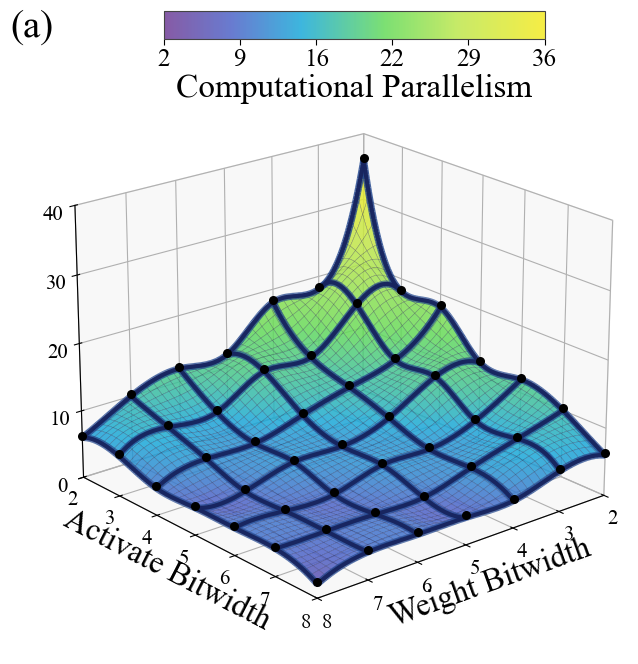

In [11]:
# Purpose: Compute and show the single-DSP48E2 2-8 bit parallelism surface.
# Compute and show the single-DSP48E2 2-8 bit parallelism surface.
act_bits, weight_bits, packing_grid = build_packing_grid(
    act_bits=range(2, 9),
    weight_bits=range(2, 9),
    X_lim=17,
    Y_lim=26,
    R_lim=47,
)
print("Packing matrix (rows = activation bits 2..8, columns = weight bits 2..8):")
print(packing_grid)

plot_cfg = {
    "fig_size": (8.1, 7.45),           # Overall figure size.
    "view_elev": 21,                   # 3D view elevation.
    "view_azim": 50,                   # 3D view azimuth.
    "surface_alpha": 0.84,             # Surface opacity.
    "surface_edge_lw": 0.34,           # Internal surface mesh line width.
    "curve_lw": 5,                   # Major connector-curve line width.
    "curve_overlay_lw": 3,           # Connector-curve outline width.
    "curve_color": "#24488f",         # Connector-curve color.
    "curve_overlay_color": "#17245e", # Connector-curve outline color.
    "color_gamma": 0.56,               # Colormap gamma for contrast control.
    "point_size": 28,                  # Sample-point size.
    "point_z_offset": 0.3,            # Vertical offset that keeps sample points above the surface.
    "xlabel_size": 23,                 # X-axis label font size.
    "ylabel_size": 23,                 # Y-axis label font size.
    "xtick_size": 15,                  # X-axis tick-label font size.
    "ytick_size": 15,                  # Y-axis tick-label font size.
    "ztick_size": 15,                  # Z-axis tick-label font size.
    "cbar_bottom": 0.845,              # Colorbar bottom position.
    "cbar_label_pad": 2,               # Padding between the colorbar label and the colorbar.
    "cbar_tick_size": 18,              # Colorbar tick-label font size.
    "cbar_label_size": 24,             # Colorbar label font size.
    "cbar_vmin": 3,                    # Colorbar lower bound.
    "cbar_vmax": 34,                   # Colorbar upper bound.
    "cbar_show_only_ends": False,       # Whether to show only endpoint colorbar tick labels.
    "panel_tag_size": 28,              # Panel tag font size.
    "panel_tag_x": 0.10,               # Panel tag x-position.
    "panel_tag_y": 0.848,              # Panel tag y-position.
}

fig, ax, used_cfg = draw_packing_surface(
    act_bits,
    weight_bits,
    packing_grid,
    cfg=plot_cfg,
)


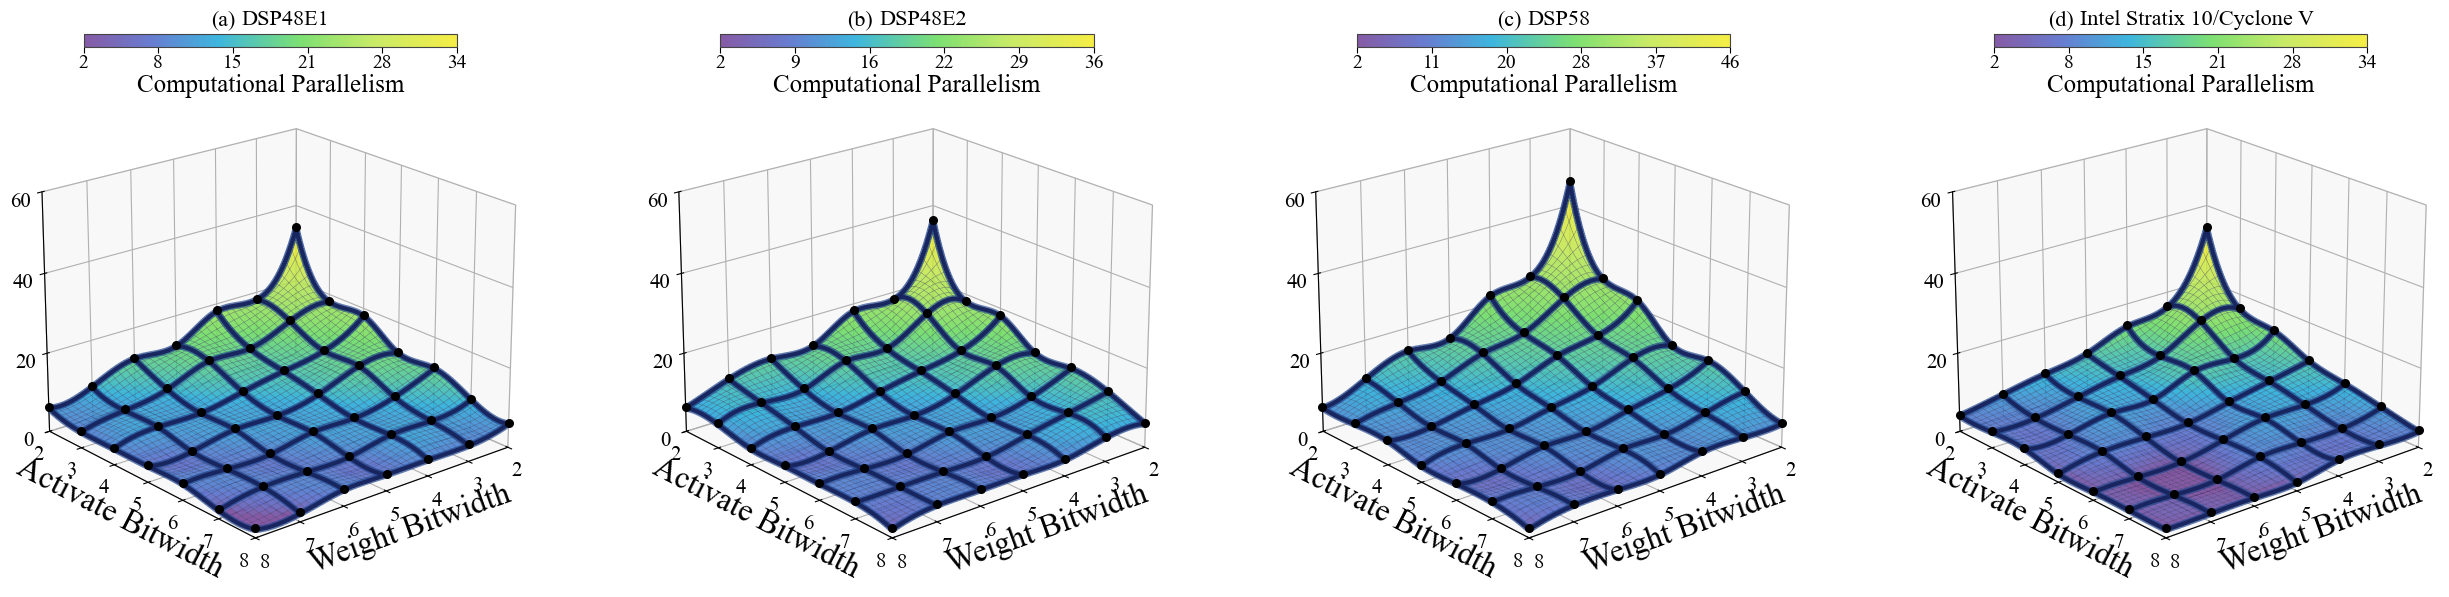

In [12]:
# Purpose: Compute and show cross-device 1x4 parallelism surfaces.
# Configure and show cross-device 1x4 parallelism surfaces.
plot_cfg_1x4_configurable = PLOT3D_DEFAULTS.copy()
if "plot_cfg_1x4" in globals():
    plot_cfg_1x4_configurable.update(plot_cfg_1x4)
elif "plot_cfg" in globals():
    plot_cfg_1x4_configurable.update(plot_cfg)

plot_cfg_1x4_configurable.update({
    "fig_size": (26, 7.2),                 # Overall figure size.
    "subplot_left": 0.018,                 # Subplot area left boundary.
    "subplot_right": 0.985,                # Subplot area right boundary.
    "subplot_bottom": 0.055,               # Subplot area bottom boundary.
    "subplot_top": 0.775,                  # Subplot area top boundary.
    "subplot_wspace": 0.055,               # Horizontal spacing between subplots.
    "subplot_cbar_width_ratio": 0.72,      # Per-subplot colorbar width relative to the subplot width.
    "subplot_cbar_left_ratio": 0.14,       # Per-subplot colorbar left offset relative to the subplot width.
    "subplot_cbar_height": 0.018,          # Per-subplot colorbar height.
    "subplot_cbar_gap": 0.030,             # Gap between each subplot and its colorbar.
    "subplot_title_gap": 0.006,            # Gap between each colorbar and its title.
    "subplot_title_weight": "normal", # Subplot title font weight.
    "subplot_cbar_tick_count": 6,          # Number of colorbar ticks per subplot.
    "cbar_tick_size": 14,                  # Colorbar tick-label font size.
    "cbar_label_size": 18,                 # Colorbar label font size.
    "cbar_label_pad": 1,                   # Padding between the colorbar label and the colorbar.
    "cbar_tick_pad": 1,                    # Padding between colorbar ticks and the colorbar.
    "use_common_z_axis": True,            # Whether all subplots share one z-axis scale.
    "common_zmin": 0,                     # Shared z-axis lower bound.
    "common_zmax": 50,                    # Shared z-axis upper bound.
    "common_z_step": 10,                  # Shared z-axis tick step.
    "auto_common_z_axis": True,           # Whether to build the shared z-axis from current data.
    "auto_subplot_z_axis": True,          # Whether each subplot scales its z-axis from its own data.
    "z_axis_min": 0,                      # Automatic z-axis lower bound.
    "z_axis_tick_count": 5,               # Target tick count for automatic z-axis scaling.
    "show_panel_tag": True,                # Whether to show panel tags.
    "panel_tag_size": 16,                  # Panel tag font size.
    "show_device_name": True,              # Whether to show device names.
    "device_name_size": 16,                # Device-name font size.
    "title_split_gap": 0.0025,             # Horizontal gap between panel tags and device names.
})


device_z_axis_cfgs = {
    "DSP48E1": {"zmin": 0, "zmax": 40, "zstep": 10},
    "DSP48E2": {"zmin": 0, "zmax": 40, "zstep": 10},
    "DSP58": {"zmin": 0, "zmax": 50, "zstep": 10},
    "Intel Stratix 10/Cyclone V": {"zmin": 0, "zmax": 40, "zstep": 10},
}

device_configs_configurable = [
    {"panel_tag": "(a)", "name": "DSP48E1", "X_lim": 17, "Y_lim": 24, "R_lim": 47},
    {"panel_tag": "(b)", "name": "DSP48E2", "X_lim": 17, "Y_lim": 26, "R_lim": 47},
    {"panel_tag": "(c)", "name": "DSP58", "X_lim": 23, "Y_lim": 26, "R_lim": 57},
    {"panel_tag": "(d)", "name": "Intel Stratix 10/Cyclone V", "X_lim": 18, "Y_lim": 18, "R_lim": 35},
]

subplot_data_configurable = []
for device_cfg in device_configs_configurable:
    act_bits_dev, weight_bits_dev, packing_grid_dev = build_packing_grid(
        act_bits=range(2, 9),
        weight_bits=range(2, 9),
        X_lim=device_cfg["X_lim"],
        Y_lim=device_cfg["Y_lim"],
        R_lim=device_cfg["R_lim"],
    )
    subplot_data_configurable.append({
        "panel_tag": device_cfg["panel_tag"],
        "name": device_cfg["name"],
        "act_bits": act_bits_dev,
        "weight_bits": weight_bits_dev,
        "grid": packing_grid_dev,
        "cbar_vmin": int(np.min(packing_grid_dev)),
        "cbar_vmax": int(np.max(packing_grid_dev)),
    })

common_z_axis_cfg_configurable = build_auto_axis_cfg_from_grids(
    [item["grid"] for item in subplot_data_configurable],
    zmin=plot_cfg_1x4_configurable["z_axis_min"],
    tick_count=plot_cfg_1x4_configurable["z_axis_tick_count"],
)

fig = plt.figure(figsize=plot_cfg_1x4_configurable["fig_size"])
fig.subplots_adjust(
    left=plot_cfg_1x4_configurable["subplot_left"],
    right=plot_cfg_1x4_configurable["subplot_right"],
    bottom=plot_cfg_1x4_configurable["subplot_bottom"],
    top=plot_cfg_1x4_configurable["subplot_top"],
    wspace=plot_cfg_1x4_configurable["subplot_wspace"],
)

for subplot_idx, subplot_item in enumerate(subplot_data_configurable, start=1):
    ax = fig.add_subplot(1, 4, subplot_idx, projection="3d", computed_zorder=False)

    cfg_local = PLOT3D_DEFAULTS.copy()
    cfg_local.update(plot_cfg_1x4_configurable)
    cfg_local["cbar_vmin"] = subplot_item["cbar_vmin"]
    cfg_local["cbar_vmax"] = subplot_item["cbar_vmax"]

    surface = draw_packing_surface_subplot_configurable(
        ax,
        subplot_item["act_bits"],
        subplot_item["weight_bits"],
        subplot_item["grid"],
        cfg_local,
    )
    apply_subplot_z_axis_configurable(ax, subplot_item["name"], subplot_item["grid"], cfg_local, device_z_axis_cfgs, common_z_axis_cfg_configurable)
    add_subplot_colorbar_configurable(fig, ax, surface, cfg_local, subplot_item)

plt.show()
